# 📊 EDA — FineHARD Dataset (FG-CLIP)

**Fine-Grained Visual Grounding + Recaption + Hard Negative**  
Path: `/home/nhan/Repo/UltraEdit/FineHARD/`

### Schema mỗi record trong JSON:
| Field | Type | Mô tả |
|-------|------|--------|
| `caption` | str | Caption dài, chi tiết cho toàn ảnh |
| `short_caption` | str | Caption ngắn cho toàn ảnh |
| `f_path` | str | Đường dẫn ảnh tương đối (grit-20m/...) |
| `width` / `height` | int | Kích thước ảnh gốc |
| `id` | str | ID ảnh (e.g. `"8_662273"`) |
| `bbox_info` | list | Danh sách bounding box: `bbox[x1,y1,x2,y2,score]`, `short_expr`, `long_expr`, `flag_short_neg`, `short_expr_negs` |


---
## 📁 Bước 1 — Unzip toàn bộ file trong FineHARD

`json_files.zip` đã unzip. Còn 21 file `coyo_image_*.zip` chứa metadata parquet (url, width, height) cần unzip.


In [4]:
# ── Kiểm tra sau khi unzip ───────────────────────────────────────────────────
import os
from pathlib import Path

FINEHARD_DIR = Path('/home/nhan/Repo/UltraEdit/FineHARD')

print(f'📂 Cấu trúc thư mục {FINEHARD_DIR}:\n')
for item in sorted(FINEHARD_DIR.iterdir()):
    if item.is_dir():
        n_files = sum(1 for _ in item.rglob('*') if _.is_file())
        print(f'  📁 {item.name}/   ({n_files:,} files)')
    elif item.suffix == '.zip':
        size_mb = item.stat().st_size / 1024 / 1024
        print(f'  🗜️  {item.name}   ({size_mb:.0f} MB) — chưa unzip')
    else:
        print(f'  📄 {item.name}')


📂 Cấu trúc thư mục /home/nhan/Repo/UltraEdit/FineHARD:

  📁 .git/   (55 files)
  📄 .gitattributes
  📄 README.md
  📁 coyo_image_0/   (100 files)
  📁 coyo_image_1/   (100 files)
  📁 coyo_image_10/   (100 files)
  📁 coyo_image_11/   (100 files)
  📁 coyo_image_12/   (100 files)
  📁 coyo_image_13/   (100 files)
  📁 coyo_image_14/   (100 files)
  📁 coyo_image_15/   (100 files)
  📁 coyo_image_16/   (100 files)
  📁 coyo_image_17/   (100 files)
  📁 coyo_image_18/   (100 files)
  📁 coyo_image_19/   (100 files)
  📁 coyo_image_2/   (100 files)
  📁 coyo_image_20/   (51 files)
  📁 coyo_image_3/   (100 files)
  📁 coyo_image_4/   (100 files)
  📁 coyo_image_5/   (100 files)
  📁 coyo_image_6/   (100 files)
  📁 coyo_image_7/   (100 files)
  📁 coyo_image_8/   (100 files)
  📁 coyo_image_9/   (100 files)
  📁 json_files/   (3,472 files)
  📁 url2key_jsons/   (21 files)


---
## 📂 Bước 2 — Load toàn bộ JSON annotations


In [5]:
# ── Import thư viện ──────────────────────────────────────────────────────────
import json, re
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (13, 5), 'figure.dpi': 100})

FINEHARD_DIR = Path('/home/nhan/Repo/UltraEdit/FineHARD')
JSON_DIR     = FINEHARD_DIR / 'json_files'
print('✅ Thư viện sẵn sàng!')


✅ Thư viện sẵn sàng!


/home/nhan/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# ── Load JSON có kiểm soát memory ────────────────────────────────────────────
# Tổng 3,472 file = ~33GB → KHÔNG load tất cả vào RAM cùng lúc
# Strategy: scan nhanh để đếm, rồi load SAMPLE để EDA

import os, gc

json_files = sorted(JSON_DIR.glob('*.json'))
print(f'📦 Tổng số file JSON: {len(json_files):,}')

# ── Bước 1: Scan nhanh — đếm records & ước lượng RAM ─────────────────────────
print('\n🔄 Scanning (đọc 50 file đầu để ước lượng)...')
sample_counts = []
for jf in json_files[:50]:
    with open(jf, 'r') as f:
        d = json.load(f)
    sample_counts.append(len(d))
    del d; gc.collect()

avg_per_file   = sum(sample_counts) / len(sample_counts)
total_est      = int(avg_per_file * len(json_files))
size_per_rec   = os.path.getsize(json_files[0]) / sample_counts[0] / 1024  # KB/record
ram_est_gb     = size_per_rec * total_est / 1024 / 1024

print(f'   Records/file (avg)    : {avg_per_file:.0f}')
print(f'   Ước tính tổng records : {total_est:,}')
print(f'   Ước tính RAM cần      : {ram_est_gb:.1f} GB')

# ── Bước 2: Chọn sample size phù hợp với RAM ─────────────────────────────────
import psutil
available_gb = psutil.virtual_memory().available / 1024**3
print(f'\n💾 RAM khả dụng hiện tại: {available_gb:.1f} GB')

# Dùng tối đa 20% RAM khả dụng cho data
safe_gb       = available_gb * 0.02
SAMPLE_FILES  = min(len(json_files), max(10, int(safe_gb / (ram_est_gb / len(json_files)))))
print(f'   → Sẽ load {SAMPLE_FILES:,} / {len(json_files):,} files '
      f'(~{SAMPLE_FILES/len(json_files)*100:.0f}% dataset)')

# ── Bước 3: Load SAMPLE_FILES file ───────────────────────────────────────────
import random
random.seed(42)
selected_files = sorted(random.sample(json_files, SAMPLE_FILES))

all_records = []
for jf in tqdm(selected_files, desc='Loading JSON'):
    with open(jf, 'r', encoding='utf-8') as f:
        data = json.load(f)
    all_records.extend(data)

print(f'\n✅ Đã load: {len(all_records):,} records từ {SAMPLE_FILES:,} files')
print(f'📋 Top-level keys : {list(all_records[0].keys())}')
print(f'📋 bbox_info keys : {list(all_records[0]["bbox_info"][0].keys())}')


📦 Tổng số file JSON: 3,472

🔄 Scanning (đọc 50 file đầu để ước lượng)...
   Records/file (avg)    : 933
   Ước tính tổng records : 3,241,042
   Ước tính RAM cần      : 8.0 GB

💾 RAM khả dụng hiện tại: 6.8 GB
   → Sẽ load 59 / 3,472 files (~2% dataset)


Loading JSON: 100%|██████████| 59/59 [00:06<00:00,  9.51it/s]


✅ Đã load: 179,845 records từ 59 files
📋 Top-level keys : ['caption', 'bbox_info', 'f_path', 'width', 'height', 'short_caption', 'id']
📋 bbox_info keys : ['bbox', 'short_expr', 'long_expr', 'flag_short_neg']


In [7]:
# ── Xây dựng DataFrame image-level ──────────────────────────────────────────
rows = []
for r in all_records:
    bbox_list = r.get('bbox_info', [])
    n_bbox = len(bbox_list)
    n_hard_neg = sum(1 for b in bbox_list if b.get('flag_short_neg', 0) == 1)
    
    # Tính area bbox trung bình (normalized)
    areas = []
    for b in bbox_list:
        bx = b['bbox']
        areas.append((bx[2] - bx[0]) * (bx[3] - bx[1]))
    avg_area = np.mean(areas) if areas else 0.0
    
    rows.append({
        'id':              r.get('id', ''),
        'f_path':          r.get('f_path', ''),
        'width':           r.get('width', np.nan),
        'height':          r.get('height', np.nan),
        'caption_words':   len(re.findall(r'\b\w+\b', r.get('caption', ''))),
        'short_cap_words': len(re.findall(r'\b\w+\b', r.get('short_caption', ''))),
        'n_bbox':          n_bbox,
        'n_hard_neg':      n_hard_neg,
        'hard_neg_ratio':  n_hard_neg / n_bbox if n_bbox else 0.0,
        'avg_bbox_area':   avg_area,
        'coyo_split':      r.get('f_path', '').split('/')[2] if r.get('f_path') else '',
    })

df = pd.DataFrame(rows)
print(f'✅ DataFrame image-level: {df.shape[0]:,} hàng × {df.shape[1]} cột')
df.head(3)


✅ DataFrame image-level: 179,845 hàng × 11 cột


,id,f_path,width,height,caption_words,short_cap_words,n_bbox,n_hard_neg,hard_neg_ratio,avg_bbox_area,coyo_split
0,3_529850,grit-20m/data-12m/coyo_image_3/00052/000529850...,533,280,240,42,2,0,0.0,0.473018,coyo_image_3
1,6_465501,grit-20m/data-12m/coyo_image_6/00046/000465501...,391,450,151,29,1,0,0.0,0.979340,coyo_image_6
2,10_583677,grit-20m/data-12m/coyo_image_10/00058/00058367...,450,300,139,30,1,0,0.0,0.505371,coyo_image_10


---
## 📈 Bước 3 — Thống kê tổng quan


In [8]:
# ── Thống kê tổng quan ───────────────────────────────────────────────────────
total_images = len(df)
total_bboxes = df['n_bbox'].sum()
total_hard_neg = df['n_hard_neg'].sum()

print('=' * 60)
print('📊 TỔNG QUAN FineHARD Dataset')
print('=' * 60)
print(f'  🖼️  Tổng số ảnh (image-level records) : {total_images:>12,}')
print(f'  📦  Tổng số bounding boxes            : {total_hard_neg + (total_bboxes - total_hard_neg):>12,}')
print(f'  ❌  Trong đó có hard negative         : {total_hard_neg:>12,} ({total_hard_neg/total_bboxes*100:.1f}%)')
print(f'  ✅  Không có hard negative             : {total_bboxes - total_hard_neg:>12,} ({(1 - total_hard_neg/total_bboxes)*100:.1f}%)')
print(f'  📂  Số coyo_image split               : {df["coyo_split"].nunique():>12,}')
print()
print('📋 Thống kê mô tả:')
desc_cols = ['caption_words', 'short_cap_words', 'n_bbox', 'n_hard_neg',
             'hard_neg_ratio', 'avg_bbox_area', 'width', 'height']
df[desc_cols].describe().round(3)


📊 TỔNG QUAN FineHARD Dataset
  🖼️  Tổng số ảnh (image-level records) :      179,845
  📦  Tổng số bounding boxes            :      607,746
  ❌  Trong đó có hard negative         :      166,142 (27.3%)
  ✅  Không có hard negative             :      441,604 (72.7%)
  📂  Số coyo_image split               :           21

📋 Thống kê mô tả:


,caption_words,short_cap_words,n_bbox,n_hard_neg,hard_neg_ratio,avg_bbox_area,width,height
count,179845.000,179845.000,179845.000,179845.000,179845.000,179845.000,179845.000,179845.000
mean,199.205,17.049,3.379,0.924,0.256,0.365,719.223,569.850
std,45.193,12.716,2.272,1.191,0.301,0.253,472.488,407.551
min,21.000,3.000,1.000,0.000,0.000,0.001,32.000,18.000
25%,168.000,9.000,2.000,0.000,0.000,0.181,450.000,320.000
50%,196.000,14.000,3.000,1.000,0.167,0.301,620.000,459.000
75%,227.000,20.000,4.000,1.000,0.500,0.489,862.000,682.000
max,2836.000,208.000,36.000,24.000,1.000,1.000,10642.000,14496.000


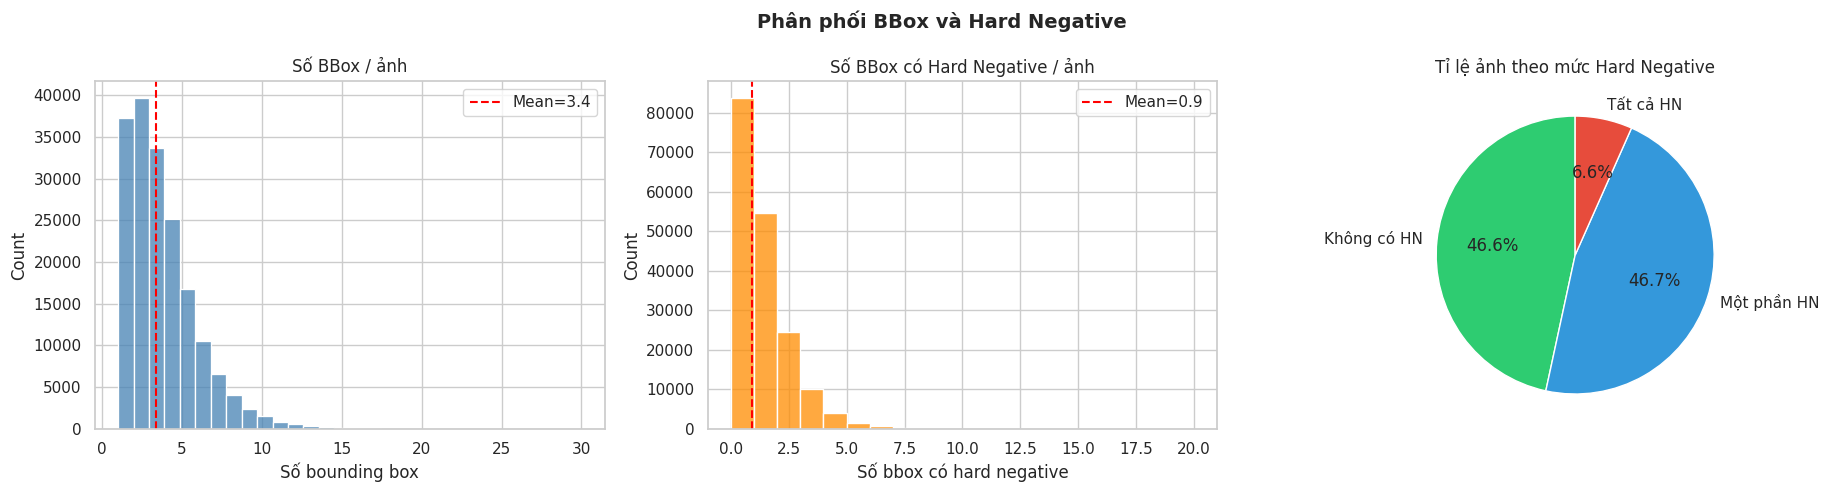

In [9]:
# ── Phân phối số BBox per image & Hard Negative ratio ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle('Phân phối BBox và Hard Negative', fontsize=14, fontweight='bold')

# 1. Số bbox mỗi ảnh
sns.histplot(df['n_bbox'].clip(upper=30), bins=30, kde=False, ax=axes[0], color='steelblue')
axes[0].set_title('Số BBox / ảnh')
axes[0].set_xlabel('Số bounding box')
axes[0].axvline(df['n_bbox'].mean(), color='red', linestyle='--',
                label=f'Mean={df["n_bbox"].mean():.1f}')
axes[0].legend()

# 2. Số hard negative mỗi ảnh
sns.histplot(df['n_hard_neg'].clip(upper=20), bins=20, kde=False, ax=axes[1], color='darkorange')
axes[1].set_title('Số BBox có Hard Negative / ảnh')
axes[1].set_xlabel('Số bbox có hard negative')
axes[1].axvline(df['n_hard_neg'].mean(), color='red', linestyle='--',
                label=f'Mean={df["n_hard_neg"].mean():.1f}')
axes[1].legend()

# 3. Tỉ lệ hard neg
pct_none  = (df['n_hard_neg'] == 0).mean() * 100
pct_some  = ((df['n_hard_neg'] > 0) & (df['n_hard_neg'] < df['n_bbox'])).mean() * 100
pct_all   = (df['n_hard_neg'] == df['n_bbox']).mean() * 100
axes[2].pie([pct_none, pct_some, pct_all],
            labels=['Không có HN', 'Một phần HN', 'Tất cả HN'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#3498db', '#e74c3c'],
            startangle=90)
axes[2].set_title('Tỉ lệ ảnh theo mức Hard Negative')

plt.tight_layout()
plt.show()


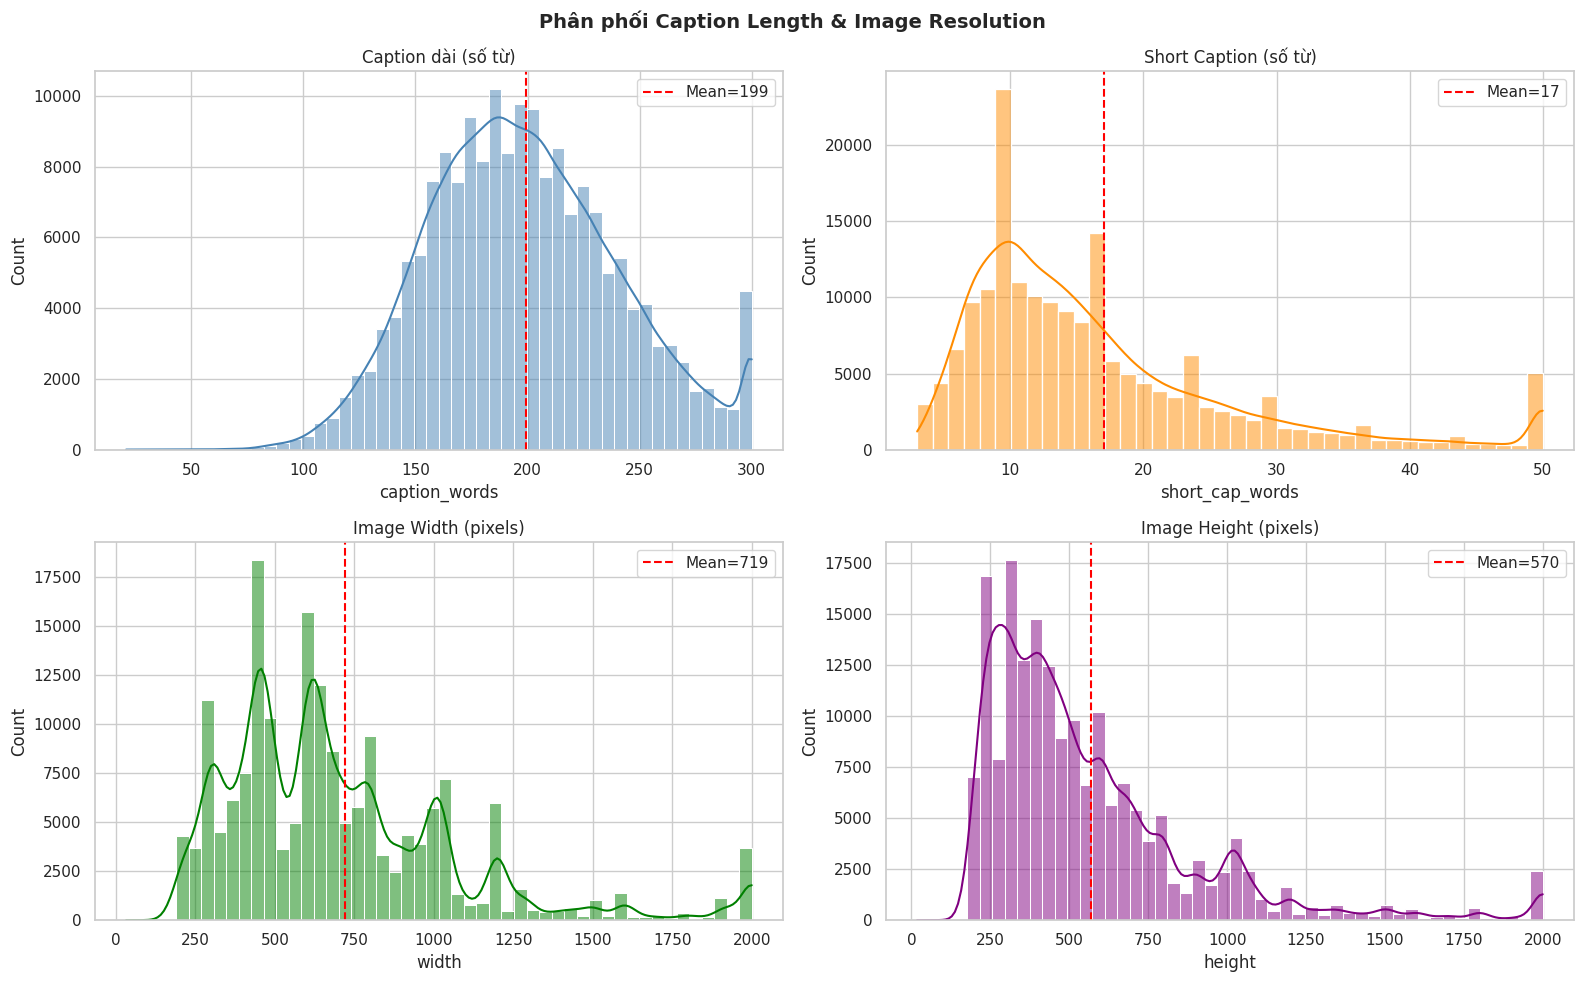

In [10]:
# ── Phân phối Caption Length & Image Resolution ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Phân phối Caption Length & Image Resolution', fontsize=14, fontweight='bold')

# Caption dài
sns.histplot(df['caption_words'].clip(upper=300), bins=50, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Caption dài (số từ)')
axes[0,0].axvline(df['caption_words'].mean(), color='red', linestyle='--',
                  label=f'Mean={df["caption_words"].mean():.0f}')
axes[0,0].legend()

# Caption ngắn
sns.histplot(df['short_cap_words'].clip(upper=50), bins=40, kde=True, ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Short Caption (số từ)')
axes[0,1].axvline(df['short_cap_words'].mean(), color='red', linestyle='--',
                  label=f'Mean={df["short_cap_words"].mean():.0f}')
axes[0,1].legend()

# Width
valid_w = df['width'].dropna()
sns.histplot(valid_w.clip(upper=2000), bins=50, kde=True, ax=axes[1,0], color='green')
axes[1,0].set_title('Image Width (pixels)')
axes[1,0].axvline(valid_w.mean(), color='red', linestyle='--',
                  label=f'Mean={valid_w.mean():.0f}')
axes[1,0].legend()

# Height
valid_h = df['height'].dropna()
sns.histplot(valid_h.clip(upper=2000), bins=50, kde=True, ax=axes[1,1], color='purple')
axes[1,1].set_title('Image Height (pixels)')
axes[1,1].axvline(valid_h.mean(), color='red', linestyle='--',
                  label=f'Mean={valid_h.mean():.0f}')
axes[1,1].legend()

plt.tight_layout()
plt.show()


---
## 🏷️ Bước 4 — Phân tích BBox-level: short_expr & hard negatives


In [11]:
# ── Xây dựng DataFrame bbox-level ────────────────────────────────────────────
STOPWORDS = {'a','an','the','and','or','in','on','at','to','of','with',
             'by','is','are','was','were','it','this','that','which'}

bbox_rows = []
for r in all_records:
    img_id = r.get('id', '')
    w, h   = r.get('width', 0) or 0, r.get('height', 0) or 0
    for b in r.get('bbox_info', []):
        bx = b['bbox']
        bbox_w  = (bx[2] - bx[0]) * w if w else bx[2] - bx[0]
        bbox_h  = (bx[3] - bx[1]) * h if h else bx[3] - bx[1]
        area_n  = (bx[2] - bx[0]) * (bx[3] - bx[1])   # normalized area
        bbox_rows.append({
            'img_id':          img_id,
            'short_expr':      b.get('short_expr', ''),
            'long_expr':       b.get('long_expr', ''),
            'flag_short_neg':  b.get('flag_short_neg', 0),
            'n_neg_variants':  len(b.get('short_expr_negs', {})),
            'conf_score':      bx[4] if len(bx) > 4 else np.nan,
            'area_norm':       area_n,
            'short_expr_words': len(re.findall(r'\b\w+\b', b.get('short_expr', ''))),
            'long_expr_words':  len(re.findall(r'\b\w+\b', b.get('long_expr', ''))),
        })

df_bbox = pd.DataFrame(bbox_rows)
print(f'✅ DataFrame bbox-level: {len(df_bbox):,} hàng × {df_bbox.shape[1]} cột')
print(f'   Hard negative bboxes : {df_bbox["flag_short_neg"].sum():,} '
      f'({df_bbox["flag_short_neg"].mean()*100:.1f}%)')
df_bbox.head(5)


✅ DataFrame bbox-level: 607,746 hàng × 9 cột
   Hard negative bboxes : 166,142 (27.3%)


,img_id,short_expr,long_expr,flag_short_neg,n_neg_variants,conf_score,area_norm,short_expr_words,long_expr_words
0,3_529850,a straightforward line chart,a straightforward line chart without any addit...,0,0,0.596176,0.726272,4,11
1,3_529850,a straightforward line chart,a straightforward line chart without any addit...,0,0,0.407912,0.219763,4,11
2,6_465501,the image,the image,0,0,0.705368,0.979340,2,2
3,10_583677,the ceramic bowl,the ceramic bowl,0,0,0.815987,0.505371,3,3
4,13_533281,the dish,the dish,0,0,0.477039,0.881039,2,2


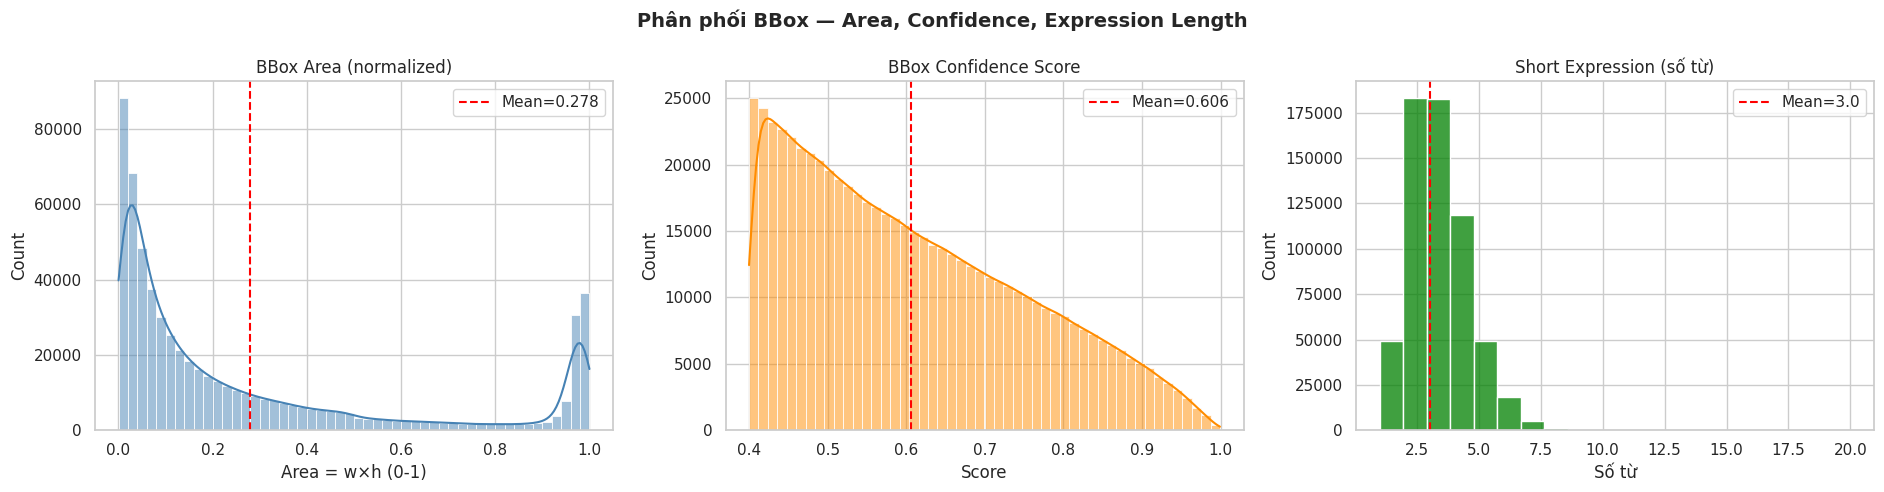

In [12]:
# ── Phân phối BBox Area, Confidence Score, Expression Length ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle('Phân phối BBox — Area, Confidence, Expression Length', fontsize=14, fontweight='bold')

sns.histplot(df_bbox['area_norm'].clip(upper=1), bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('BBox Area (normalized)')
axes[0].set_xlabel('Area = w×h (0-1)')
axes[0].axvline(df_bbox['area_norm'].mean(), color='red', linestyle='--',
                label=f'Mean={df_bbox["area_norm"].mean():.3f}')
axes[0].legend()

sns.histplot(df_bbox['conf_score'].dropna(), bins=50, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('BBox Confidence Score')
axes[1].set_xlabel('Score')
axes[1].axvline(df_bbox['conf_score'].mean(), color='red', linestyle='--',
                label=f'Mean={df_bbox["conf_score"].mean():.3f}')
axes[1].legend()

sns.histplot(df_bbox['short_expr_words'].clip(upper=20), bins=20, kde=False, ax=axes[2], color='green')
axes[2].set_title('Short Expression (số từ)')
axes[2].set_xlabel('Số từ')
axes[2].axvline(df_bbox['short_expr_words'].mean(), color='red', linestyle='--',
                label=f'Mean={df_bbox["short_expr_words"].mean():.1f}')
axes[2].legend()

plt.tight_layout()
plt.show()


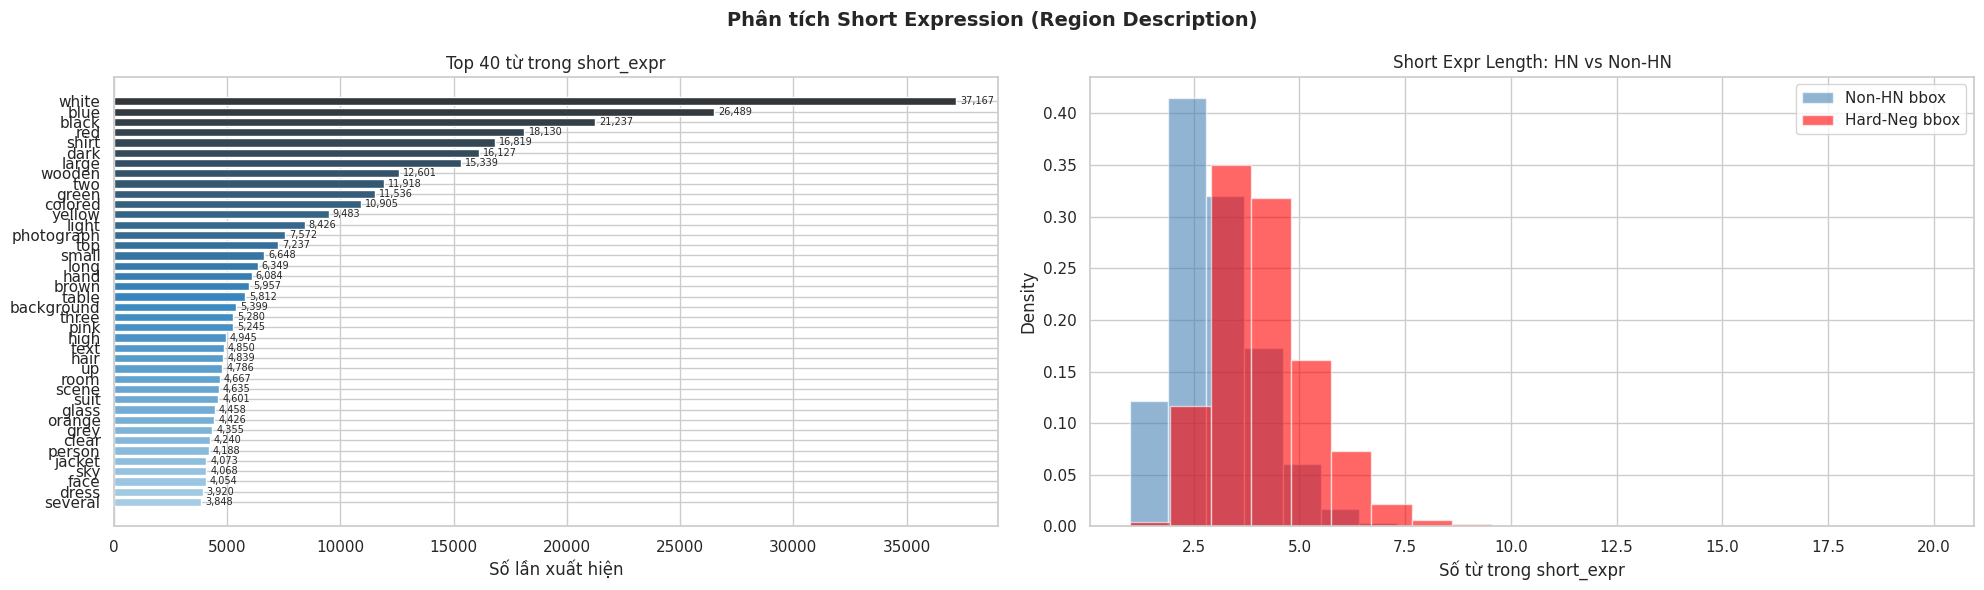

In [13]:
# ── Top 40 từ xuất hiện nhiều nhất trong short_expr ─────────────────────────
STOPWORDS = {'a','an','the','and','or','in','on','at','to','of','with',
             'by','is','are','was','were','it','this','that','which','has',
             'its','be','for','as','from','an'}

all_words = []
for expr in df_bbox['short_expr']:
    words = re.findall(r'\b[a-zA-Z]+\b', str(expr).lower())
    all_words.extend([w for w in words if w not in STOPWORDS and len(w) > 1])

top_words = Counter(all_words).most_common(40)
words, counts = zip(*top_words)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Phân tích Short Expression (Region Description)', fontsize=14, fontweight='bold')

# Bar chart top 40 từ
palette = sns.color_palette('Blues_d', 40)
axes[0].barh(words[::-1], counts[::-1], color=palette)
axes[0].set_title('Top 40 từ trong short_expr')
axes[0].set_xlabel('Số lần xuất hiện')
for i, (w, c) in enumerate(zip(words[::-1], counts[::-1])):
    axes[0].text(c + counts[0]*0.005, i, f'{c:,}', va='center', fontsize=7)

# So sánh hard neg vs non-hard neg: short_expr_words distribution
hn_words  = df_bbox[df_bbox['flag_short_neg']==1]['short_expr_words'].clip(upper=20)
non_words = df_bbox[df_bbox['flag_short_neg']==0]['short_expr_words'].clip(upper=20)
axes[1].hist(non_words, bins=20, alpha=0.6, color='steelblue', label='Non-HN bbox', density=True)
axes[1].hist(hn_words,  bins=20, alpha=0.6, color='red',       label='Hard-Neg bbox', density=True)
axes[1].set_title('Short Expr Length: HN vs Non-HN')
axes[1].set_xlabel('Số từ trong short_expr')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()


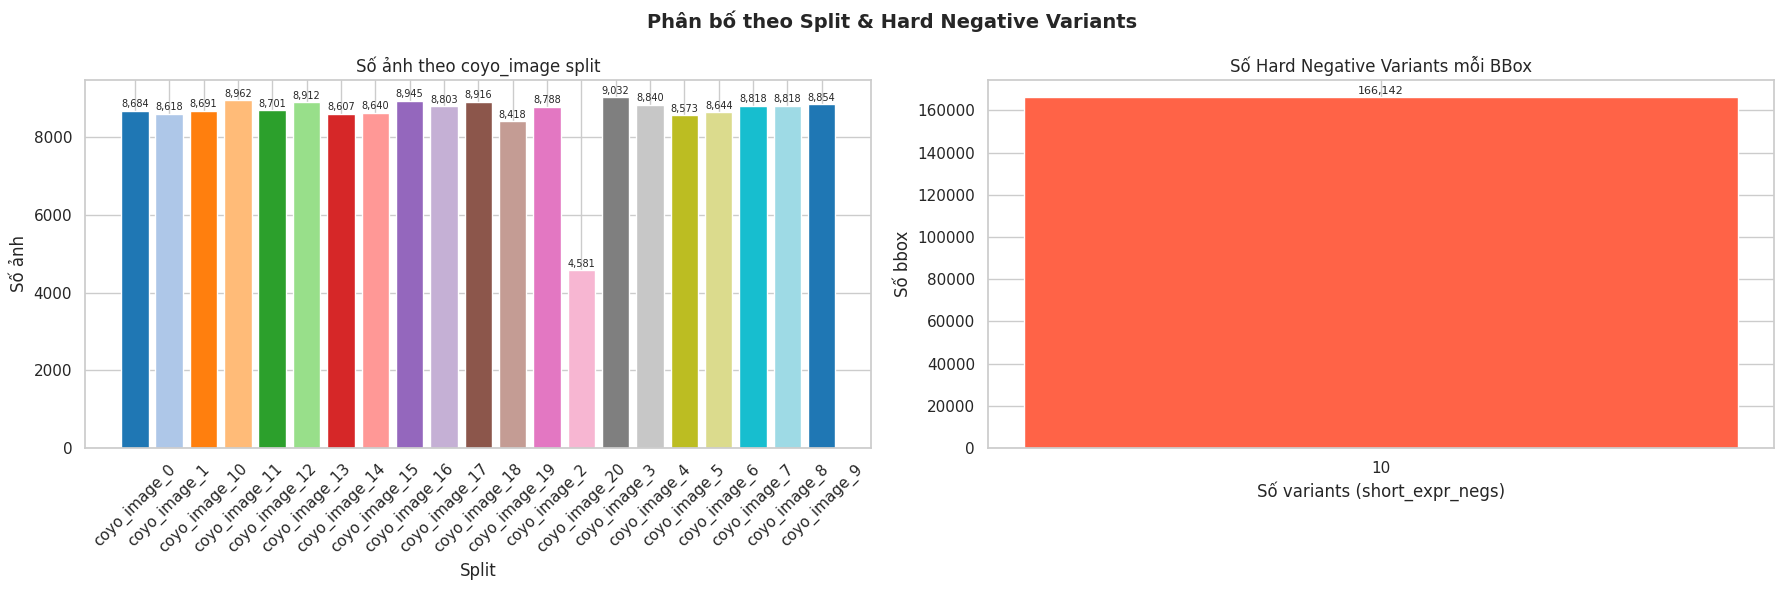

In [14]:
# ── Phân bố coyo_image split & số hard negative variant ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Phân bố theo Split & Hard Negative Variants', fontsize=14, fontweight='bold')

# Số ảnh theo coyo split
split_counts = df['coyo_split'].value_counts().sort_index()
axes[0].bar(split_counts.index, split_counts.values,
            color=sns.color_palette('tab20', len(split_counts)))
axes[0].set_title('Số ảnh theo coyo_image split')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Số ảnh')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(split_counts.values):
    axes[0].text(i, v + split_counts.max()*0.01, f'{v:,}', ha='center', fontsize=7)

# Số variants trong hard negative (0-10)
neg_variant_counts = df_bbox[df_bbox['flag_short_neg']==1]['n_neg_variants'].value_counts().sort_index()
axes[1].bar(neg_variant_counts.index.astype(str), neg_variant_counts.values, color='tomato')
axes[1].set_title('Số Hard Negative Variants mỗi BBox')
axes[1].set_xlabel('Số variants (short_expr_negs)')
axes[1].set_ylabel('Số bbox')
for i, v in enumerate(neg_variant_counts.values):
    axes[1].text(i, v + neg_variant_counts.max()*0.01, f'{v:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


---
## 🖼️ Bước 5 — Visualize mẫu annotation (BBox + Caption)


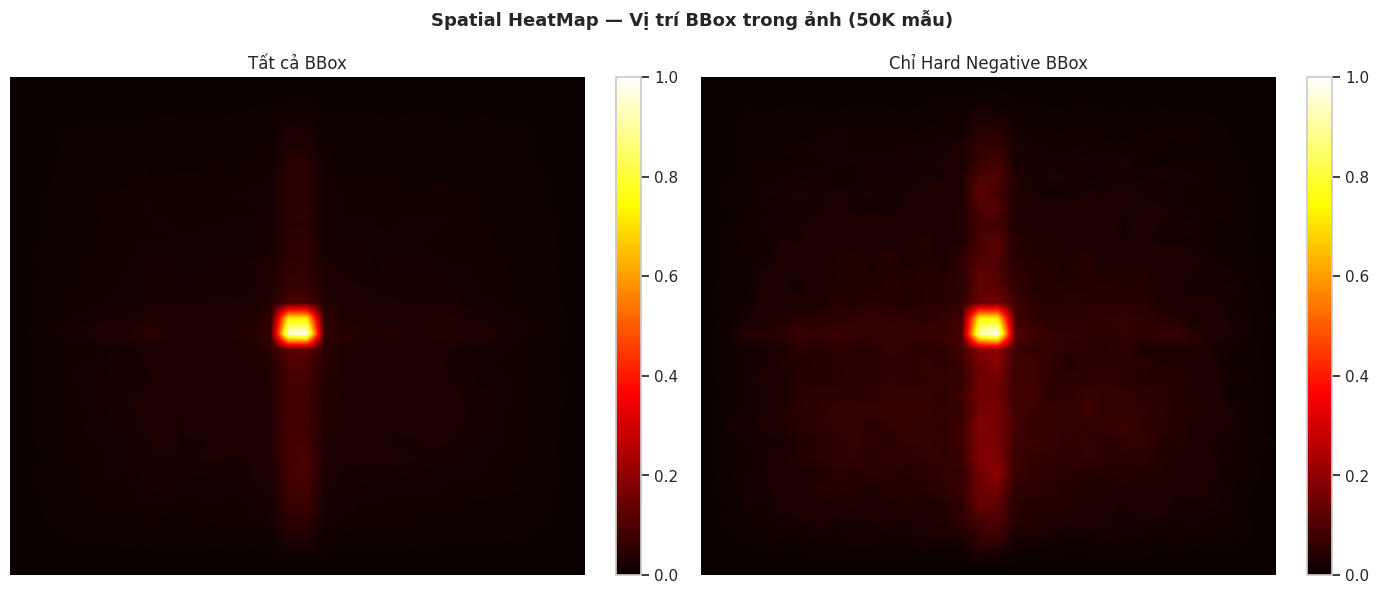

💡 Màu đỏ/vàng = vùng xuất hiện nhiều nhất trong dataset


In [15]:
# ── Spatial HeatMap — BBox thường nằm ở đâu trong ảnh? ──────────────────────
import numpy as np

GRID = 32
heatmap_all = np.zeros((GRID, GRID), dtype=np.float64)
heatmap_hn  = np.zeros((GRID, GRID), dtype=np.float64)
N_SAMPLE = 200_000  # giới hạn để chạy nhanh

sample_bboxes = df_bbox.sample(min(N_SAMPLE, len(df_bbox)), random_state=42)

for _, row in sample_bboxes.iterrows():
    # bbox là normalized [x1,y1,x2,y2]
    # Tìm bbox gốc từ record (đã lưu area_norm, ta cần x1,y1,x2,y2)
    pass  # sẽ recompute trực tiếp từ all_records bên dưới

# Tính lại từ all_records
for r in all_records[:50000]:
    for b in r.get('bbox_info', []):
        bx = b['bbox']
        x1n, y1n, x2n, y2n = bx[0], bx[1], bx[2], bx[3]
        # Map vào grid
        cx = int(((x1n + x2n) / 2) * GRID)
        cy = int(((y1n + y2n) / 2) * GRID)
        cx = min(cx, GRID - 1); cy = min(cy, GRID - 1)
        heatmap_all[cy, cx] += 1
        if b.get('flag_short_neg', 0) == 1:
            heatmap_hn[cy, cx] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Spatial HeatMap — Vị trí BBox trong ảnh (50K mẫu)', fontsize=13, fontweight='bold')

im0 = axes[0].imshow(heatmap_all / heatmap_all.max(), cmap='hot', interpolation='bilinear', aspect='auto')
axes[0].set_title('Tất cả BBox')
plt.colorbar(im0, ax=axes[0], fraction=0.046)
axes[0].axis('off')

im1 = axes[1].imshow(heatmap_hn / (heatmap_hn.max() + 1e-9), cmap='hot', interpolation='bilinear', aspect='auto')
axes[1].set_title('Chỉ Hard Negative BBox')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
axes[1].axis('off')

plt.tight_layout()
plt.show()
print('💡 Màu đỏ/vàng = vùng xuất hiện nhiều nhất trong dataset')


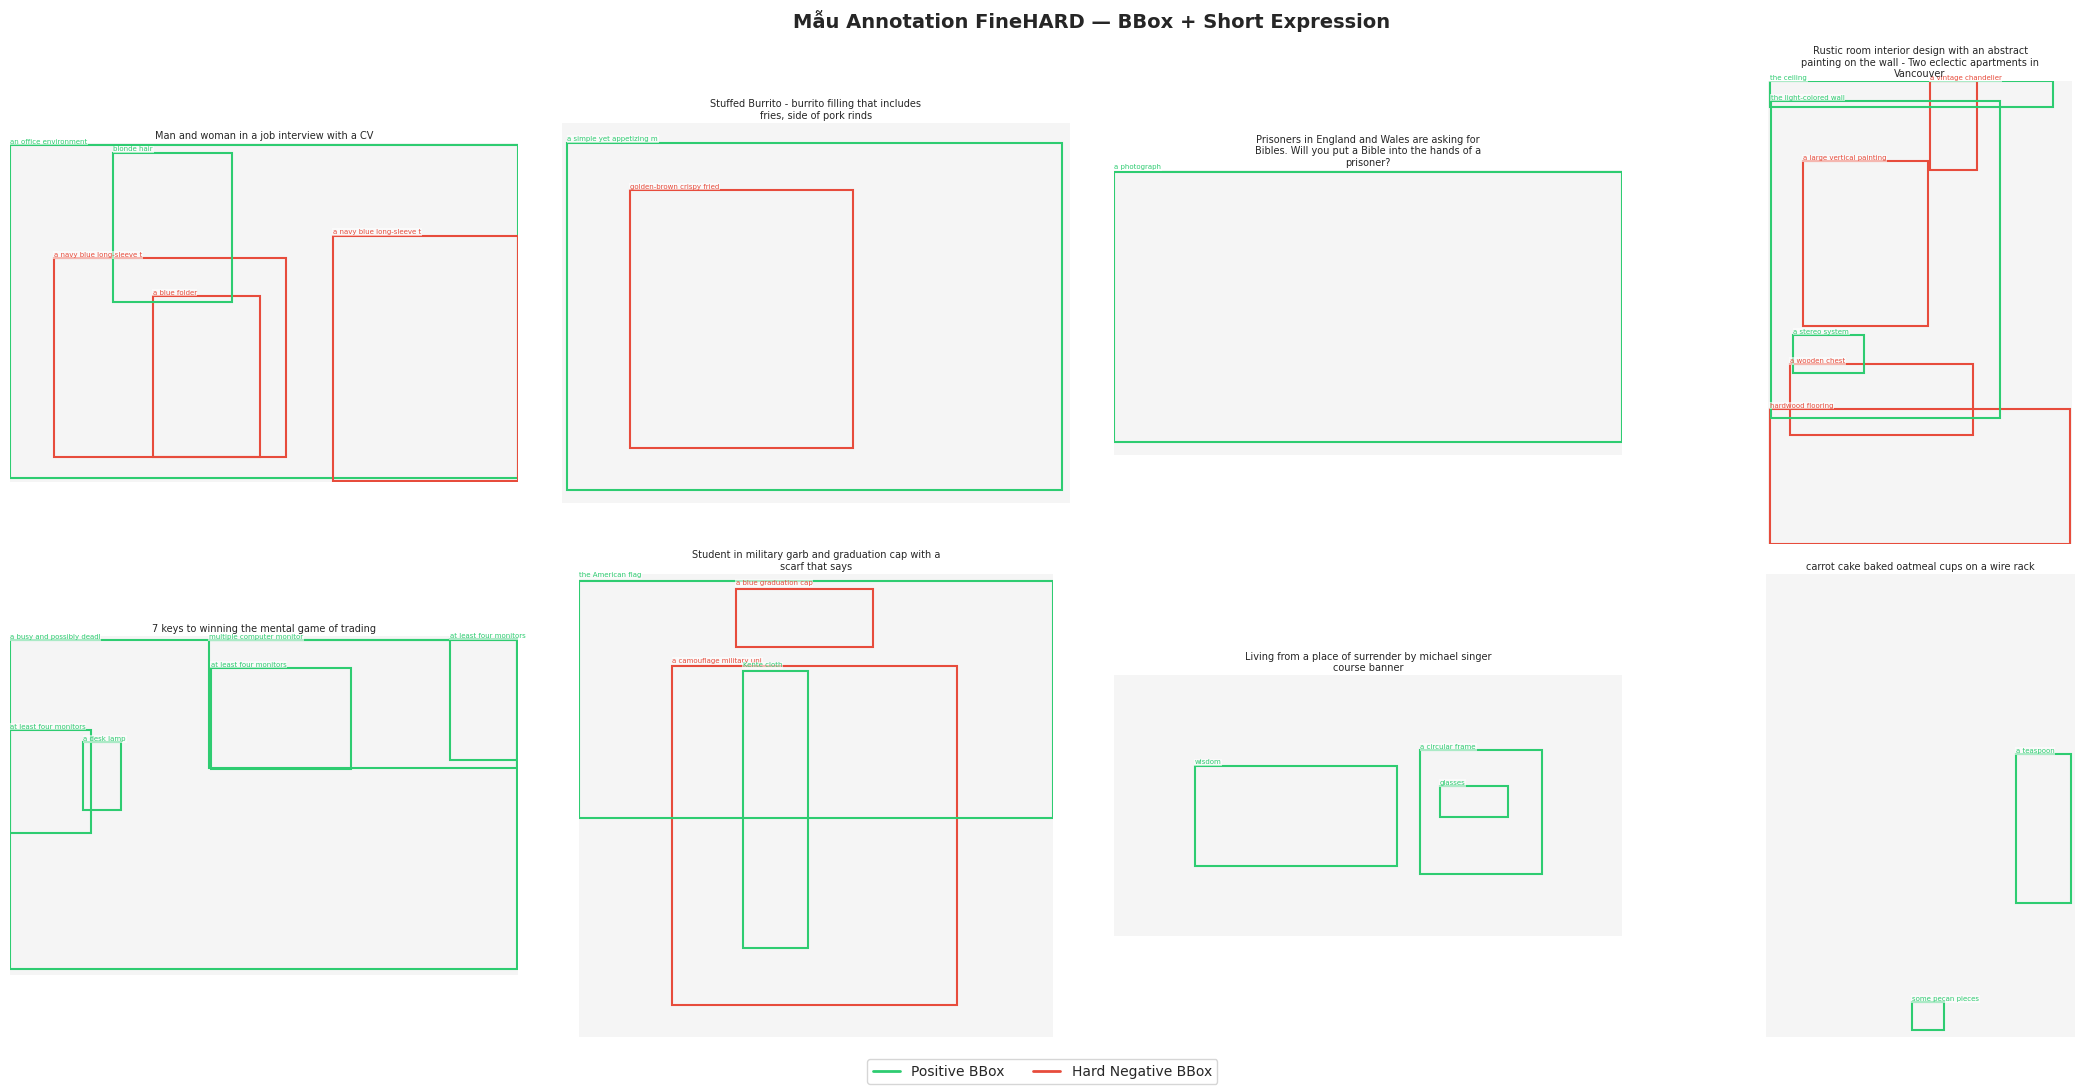

In [16]:
# ── Visualize 8 mẫu annotation (bbox + caption) ──────────────────────────────
# Vẽ bounding box trực tiếp trên canvas trắng (không cần ảnh gốc)
import random, textwrap
random.seed(99)
samples = random.sample(all_records, 8)

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.suptitle('Mẫu Annotation FineHARD — BBox + Short Expression', fontsize=14, fontweight='bold')
axes = axes.flatten()

colors_pos = '#2ecc71'  # green = positive
colors_neg = '#e74c3c'  # red   = hard negative

for ax, r in zip(axes, samples):
    w = r.get('width', 100) or 100
    h = r.get('height', 100) or 100

    # Vẽ canvas trắng với tỉ lệ aspect ratio ảnh
    canvas = np.ones((100, 100, 3), dtype=np.uint8) * 245
    ax.imshow(canvas, extent=[0, w, h, 0], aspect='auto')

    for b in r.get('bbox_info', []):
        bx = b['bbox']
        x1, y1 = bx[0] * w, bx[1] * h
        bw, bh = (bx[2] - bx[0]) * w, (bx[3] - bx[1]) * h
        is_hn = b.get('flag_short_neg', 0) == 1
        color = colors_neg if is_hn else colors_pos
        rect = patches.Rectangle((x1, y1), bw, bh,
                                   linewidth=1.5, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        label = b.get('short_expr', '')[:25]
        ax.text(x1, y1 - 2, label, color=color, fontsize=5,
                bbox=dict(facecolor='white', alpha=0.6, pad=0.5, edgecolor='none'))

    short_cap = textwrap.fill(r.get('short_caption', ''), width=50)
    ax.set_title(short_cap, fontsize=7, pad=3)
    ax.set_xlim(0, w); ax.set_ylim(h, 0)
    ax.set_aspect('equal')
    ax.axis('off')

# Legend
from matplotlib.lines import Line2D
legend = [Line2D([0],[0], color=colors_pos, lw=2, label='Positive BBox'),
          Line2D([0],[0], color=colors_neg, lw=2, label='Hard Negative BBox')]
fig.legend(handles=legend, loc='lower center', ncol=2, fontsize=10, frameon=True)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


In [17]:
# ── Tóm tắt EDA ──────────────────────────────────────────────────────────────
total_bbox = len(df_bbox)
total_hn   = int(df_bbox['flag_short_neg'].sum())
total_neg_variants = int(df_bbox['n_neg_variants'].sum())

print('=' * 65)
print('📊 TÓM TẮT EDA — FineHARD (FG-CLIP)')
print('=' * 65)
print(f'\n🖼️  IMAGES')
print(f'   Tổng số ảnh                  : {len(df):>12,}')
print(f'   Width trung bình             : {df["width"].mean():>12.0f} px')
print(f'   Height trung bình            : {df["height"].mean():>12.0f} px')
print(f'\n📝 CAPTIONS')
print(f'   Caption dài  (avg words)     : {df["caption_words"].mean():>12.1f}')
print(f'   Caption ngắn (avg words)     : {df["short_cap_words"].mean():>12.1f}')
print(f'\n📦 BOUNDING BOXES')
print(f'   Tổng số bbox                 : {total_bbox:>12,}')
print(f'   BBox / ảnh (avg)             : {df["n_bbox"].mean():>12.1f}')
print(f'   BBox area norm (avg)         : {df_bbox["area_norm"].mean():>12.4f}')
print(f'   Confidence score (avg)       : {df_bbox["conf_score"].mean():>12.4f}')
print(f'\n❌ HARD NEGATIVES')
print(f'   BBox có hard negative        : {total_hn:>12,} ({total_hn/total_bbox*100:.1f}%)')
print(f'   Tổng variants hard neg       : {total_neg_variants:>12,}')
print(f'   Variants / HN bbox (avg)     : {total_neg_variants/max(total_hn,1):>12.1f}')
print('=' * 65)


📊 TÓM TẮT EDA — FineHARD (FG-CLIP)

🖼️  IMAGES
   Tổng số ảnh                  :      179,845
   Width trung bình             :          719 px
   Height trung bình            :          570 px

📝 CAPTIONS
   Caption dài  (avg words)     :        199.2
   Caption ngắn (avg words)     :         17.0

📦 BOUNDING BOXES
   Tổng số bbox                 :      607,746
   BBox / ảnh (avg)             :          3.4
   BBox area norm (avg)         :       0.2784
   Confidence score (avg)       :       0.6056

❌ HARD NEGATIVES
   BBox có hard negative        :      166,142 (27.3%)
   Tổng variants hard neg       :    1,661,420
   Variants / HN bbox (avg)     :         10.0


In [31]:
samples = []
used_ids = set()

for r in all_records:

    id = r["id"]

    if id in used_ids:
        continue

    image_path = r["f_path"]

    for i, b in enumerate(r["bbox_info"]):

        if b.get("flag_short_neg", 0) != 1:
            continue

        negs = b.get("short_expr_negs", {})
        if not negs:
            continue

        pos_caption = b["long_expr"]

        word_count = len(pos_caption.split())
        if word_count < 15 or word_count > 30:
            continue

        bbox = b["bbox"][:4]

        # lấy đúng 1 negative
        k, neg_caption = next(iter(negs.items()))

        samples.append({
            "sample_id": f"{id}_{i}_{k}",
            "image_path": image_path,
            "bbox": bbox,
            "positive_caption": pos_caption,
            "hard_negative_caption": neg_caption
        })

        used_ids.add(id)

        break

    if len(samples) >= 10:
        break

print(samples)

[{'sample_id': '19_139827_0_0', 'image_path': 'grit-20m/data-12m/coyo_image_19/00013/000139827.jpg', 'bbox': [0.6084343910217285, 0.21073549058702257, 0.8687049865722656, 0.7008371988932292], 'positive_caption': 'a delicate wispy pattern that seems to emanate from the central mass and extend outward giving the impression of movement or diffusion', 'hard_negative_caption': 'a rich plaid pattern'}, {'sample_id': '8_114011_2_0', 'image_path': 'grit-20m/data-12m/coyo_image_8/00011/000114011.jpg', 'bbox': [2.3365020751953127e-06, 0.6488627025059291, 0.44583969116210936, 0.9901074681963239], 'positive_caption': 'a low wooden table with a carved design and a vase filled with flowers which includes what appears to be red geraniums white daisies and others', 'hard_negative_caption': 'a copper table'}, {'sample_id': '16_981249_1_0', 'image_path': 'grit-20m/data-12m/coyo_image_16/00098/000981249.jpg', 'bbox': [0.4760203467475043, 0.32575923919677735, 0.702202648586697, 0.9035039520263672], 'posit

In [32]:
import json

save_path = "ultraedit_samples_10.jsonl"

with open(save_path, "w") as f:
    for s in samples:
        f.write(json.dumps(s) + "\n")

print(f"💾 Saved → {save_path}")

💾 Saved → ultraedit_samples_10.jsonl
